In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('google-fonts.csv')

In [3]:
df.shape

(1690, 198)

In [4]:
df.head()

,family,variants_thin,variants_thinitalic,variants_extralight,variants_extralightitalic,variants_light,variants_lightitalic,variants_medium,variants_mediumitalic,variants_semibold,...,subsets_warang-citi,subsets_yezidi,subsets_yi,subsets_zanabazar-square,subsets_znamenny,category_display,category_handwriting,category_monospace,category_sans-serif,category_serif
0,ABeeZee,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,False,False,True,False
1,ADLaM Display,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,False
2,AR One Sans,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,False,False,False,True,False
3,Abel,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,False,False,False,True,False
4,Abhaya Libre,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,False,False,False,False,True


In [5]:
import matplotlib.pyplot as plt

In [6]:
from sklearn.manifold import TSNE

In [7]:
tsne = TSNE(n_components=2, verbose=1, random_state=123)
z = tsne.fit_transform(df.iloc[:,1:])

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1690 samples in 0.004s...
[t-SNE] Computed neighbors for 1690 samples in 0.369s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1690
[t-SNE] Computed conditional probabilities for sample 1690 / 1690
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.339912
[t-SNE] KL divergence after 1000 iterations: 0.434602


In [8]:
z.shape

(1690, 2)

In [9]:
z

array([[ -6.779672 , -13.281047 ],
       [ -7.8424706,  38.673218 ],
       [ 16.326447 , -14.853606 ],
       ...,
       [-26.513376 , -43.089615 ],
       [ 40.155052 ,   9.118083 ],
       [ 12.737554 ,   2.7797022]], dtype=float32)

In [10]:
df['x'] = z.T[0]
df['y'] = z.T[1]

In [11]:
df.head()

,family,variants_thin,variants_thinitalic,variants_extralight,variants_extralightitalic,variants_light,variants_lightitalic,variants_medium,variants_mediumitalic,variants_semibold,...,subsets_yi,subsets_zanabazar-square,subsets_znamenny,category_display,category_handwriting,category_monospace,category_sans-serif,category_serif,x,y
0,ABeeZee,0,0,0,0,0,0,0,0,0,...,0,0,0,False,False,False,True,False,-6.779672,-13.281047
1,ADLaM Display,0,0,0,0,0,0,0,0,0,...,0,0,0,True,False,False,False,False,-7.842471,38.673218
2,AR One Sans,0,0,0,0,0,0,1,0,1,...,0,0,0,False,False,False,True,False,16.326447,-14.853606
3,Abel,0,0,0,0,0,0,0,0,0,...,0,0,0,False,False,False,True,False,-17.895502,-9.718515
4,Abhaya Libre,0,0,0,0,0,0,1,0,1,...,0,0,0,False,False,False,False,True,20.621332,-4.883548


In [12]:
df.to_csv('google-fonts-tsne.csv', index=False)

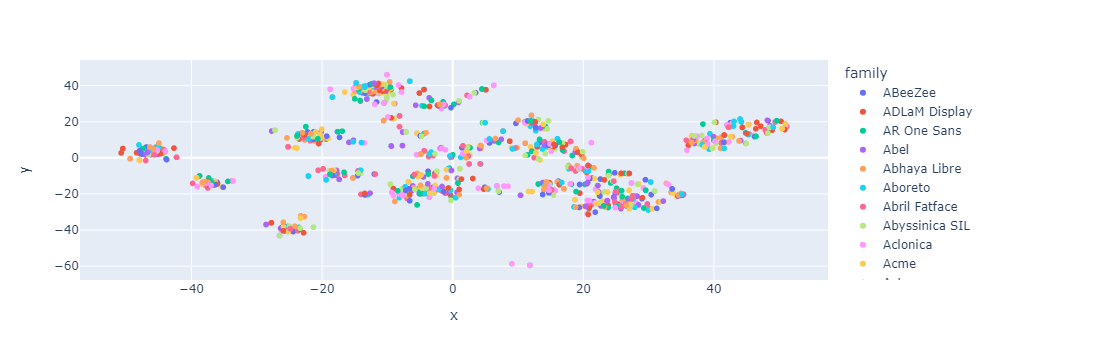

In [13]:
import plotly.express as px
fig = px.scatter(df, x="x", y="y", color="family")
fig.show()

In [14]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler

file_path = 'google-fonts-tsne.csv'  # Update with the correct file path
data = pd.read_csv(file_path)

print(data.head())

# Assuming the font vectors are in columns, replace 'vector_1', 'vector_2', etc. with actual column names
font_vectors = data.iloc[:, 1:]  # Adjust slicing based on your CSV structure

scaler = StandardScaler()
font_vectors_scaled = scaler.fit_transform(font_vectors)

# Calculate cosine distance matrix
cosine_distance_matrix = cosine_distances(font_vectors)

# Generate font pairs and their distances
font_pairs = []
font_names = data.iloc[:, 0]  # Assuming the first column contains font names

for i in range(len(font_names)):
    for j in range(i + 1, len(font_names)):
        font_pairs.append((font_names[i], font_names[j], cosine_distance_matrix[i, j]))

# Convert to DataFrame for easier viewing
font_pairs_df = pd.DataFrame(font_pairs, columns=['Font1', 'Font2', 'Cosine Distance'])

# Save to CSV if needed
font_pairs_df.to_csv('font_pairs_cosine_distances.csv', index=False)

print(font_pairs_df)


          family  variants_thin  variants_thinitalic  variants_extralight  \
0        ABeeZee              0                    0                    0   
1  ADLaM Display              0                    0                    0   
2    AR One Sans              0                    0                    0   
3           Abel              0                    0                    0   
4   Abhaya Libre              0                    0                    0   

   variants_extralightitalic  variants_light  variants_lightitalic  \
0                          0               0                     0   
1                          0               0                     0   
2                          0               0                     0   
3                          0               0                     0   
4                          0               0                     0   

   variants_medium  variants_mediumitalic  variants_semibold  ...  subsets_yi  \
0                0                 



In [16]:
import seaborn as sns

plt.figure(figsize=(12, 8))
palette = sns.color_palette("hsv", len(font_names.unique()))
sns.scatterplot(x=z[:, 0], y=z[:, 1], hue=font_names, palette=palette, legend='full')
plt.title('t-SNE Scatter Plot of Font Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(loc='best', bbox_to_anchor=(1, 1), ncol=1)
plt.show()

In [17]:
high_contrast_threshold = 0.8
moderate_contrast_threshold = 0.6
balanced_contrast_threshold = 0.4
similar_threshold = 0.2


# Classify font pairs based on cosine distance
def classify_contrast(distance):
    if distance >= high_contrast_threshold:
        return 'High Contrast'
    elif distance >= moderate_contrast_threshold:
        return 'Moderate Contrast'
    elif distance >= balanced_contrast_threshold:
        return 'Balanced Contrast'
    elif distance >= similar_threshold:
        return 'Similar'
    else:
        return 'Very Similar'

font_pairs_df['Contrast Level'] = font_pairs_df['Cosine Distance'].apply(classify_contrast)

# Save to CSV if needed
font_pairs_df.to_csv('font_pairs_contrast_levels.csv', index=False)

print(font_pairs_df)

                 Font1                 Font2  Cosine Distance  \
0              ABeeZee         ADLaM Display         1.767609   
1              ABeeZee           AR One Sans         0.730028   
2              ABeeZee                  Abel         0.177713   
3              ABeeZee          Abhaya Libre         1.222942   
4              ABeeZee               Aboreto         1.718883   
...                ...                   ...              ...   
1427200         Zeyada            Zilla Slab         1.703734   
1427201         Zeyada  Zilla Slab Highlight         1.688157   
1427202  Zhi Mang Xing            Zilla Slab         1.695468   
1427203  Zhi Mang Xing  Zilla Slab Highlight         1.680088   
1427204     Zilla Slab  Zilla Slab Highlight         0.009038   

            Contrast Level  
0            High Contrast  
1        Moderate Contrast  
2             Very Similar  
3            High Contrast  
4            High Contrast  
...                    ...  
1427200      Hig

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
font_pairs_df = pd.read_csv('font_pairs_contrast_levels.csv')

# Create the 'Font Pair' column by concatenating 'Font1' and 'Font2'
font_pairs_df['Font Pair'] = font_pairs_df['Font1'] + ' & ' + font_pairs_df['Font2']

# Define a mapping from contrast level to a numerical value for plotting
contrast_level_mapping = {
    'Very Similar': 0,
    'Similar': 1,
    'Balanced Contrast': 2,
    'Moderate Contrast': 3,
    'High Contrast': 4
}

# Add a new column for numerical contrast level
font_pairs_df['Contrast Level Value'] = font_pairs_df['Contrast Level'].map(contrast_level_mapping)

# Plotting
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Font Pair', y='Cosine Distance', hue='Contrast Level', palette='viridis', data=font_pairs_df, s=100)

# Customize plot
plt.title('Font Pairs Clustering Based on Contrast Levels')
plt.xlabel('Font Pair')
plt.ylabel('Cosine Distance')
plt.legend(title='Contrast Level')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show plot
plt.show()


In [ ]:
# Load the CSV file
df = pd.read_csv('font_pairs_contrast_levels.csv')

# Shuffle the DataFrame
df_shuffled = df.sample(frac=1).reset_index(drop=True)

# Save the shuffled DataFrame to a new CSV file
df_shuffled.to_csv('shuffled_pairs.csv', index=False)